# Chapter 5

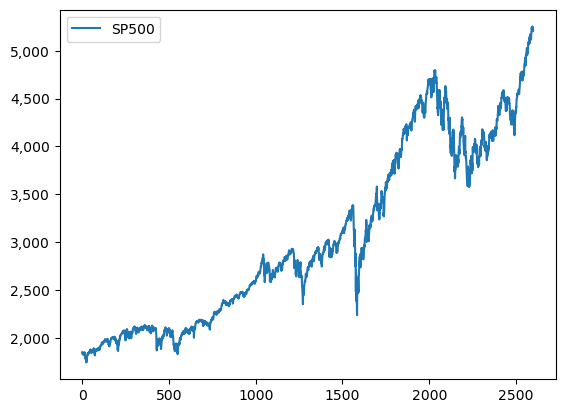

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

df = pd.read_csv('SP500.csv')

fig,ax = plt.subplots()
df.plot(ax=ax)

ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: '{:,}'.format(int(x))))

plt.show()

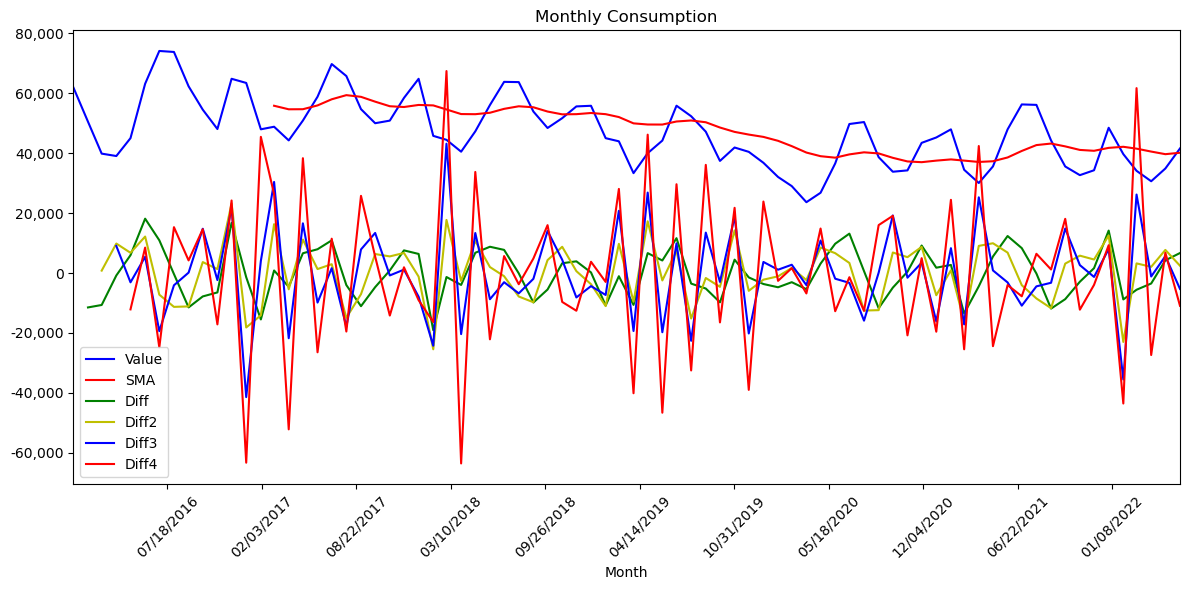

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator, FuncFormatter
import matplotlib.dates as mdates

df = pd.read_csv('MonthlyCoalConsumption.csv')
df['Month'] = pd.to_datetime(df['Month'], format='%m/%d/%Y')

df['SMA'] = df['Value'].rolling(window=15).mean()

df['Diff'] = df['Value'].diff()
df['Diff2'] = df['Diff'].diff()
df['Diff3'] = df['Diff2'].diff()
df['Diff4'] = df['Diff3'].diff()

def y_format(value, tick_number):
    return f'{int(round(value)):,}'

plt.figure(figsize=(12,6))

plt.plot(df['Month'], df['Value'], marker='', linestyle='-', color='b', label='Value')
plt.plot(df['Month'], df['SMA'], marker='', linestyle='-', color='r', label='SMA')
plt.plot(df['Month'], df['Diff'], marker='', linestyle='-', color='g', label='Diff')
plt.plot(df['Month'], df['Diff2'], marker='', linestyle='-', color='y', label='Diff2')
plt.plot(df['Month'], df['Diff3'], marker='', linestyle='-', color='b', label='Diff3')
plt.plot(df['Month'], df['Diff4'], marker='', linestyle='-', color='r', label='Diff4')

plt.xlim(pd.to_datetime('01/01/2016', format='%m/%d/%Y'), df['Month'].max())

ax = plt.gca()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m/%d/%Y'))
ax.xaxis.set_major_locator(MaxNLocator(nbins=12))

plt.xticks(rotation=45)

plt.title('Monthly Consumption')
plt.xlabel('Month')
plt.legend()

ax.yaxis.set_major_formatter(FuncFormatter(y_format))

plt.tight_layout()
plt.show()

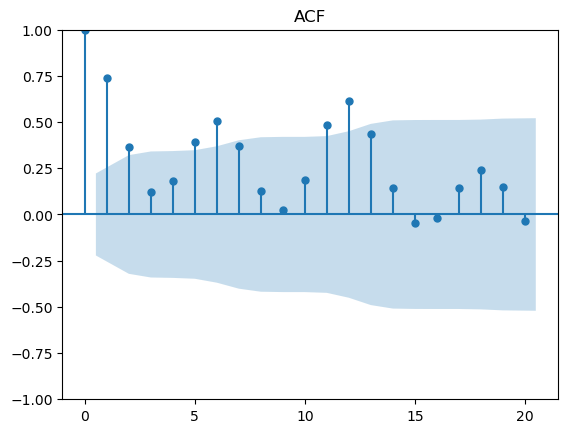

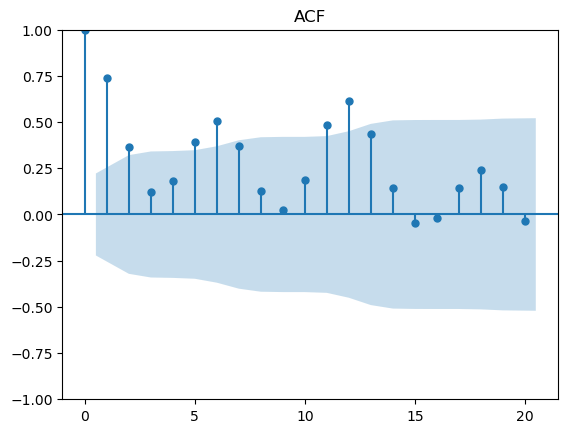

In [11]:
from statsmodels.graphics.tsaplots import plot_acf

df = pd.read_csv('MonthlyCoalConsumption.csv')

plot_acf(df['Value'], lags=20, title='ACF')

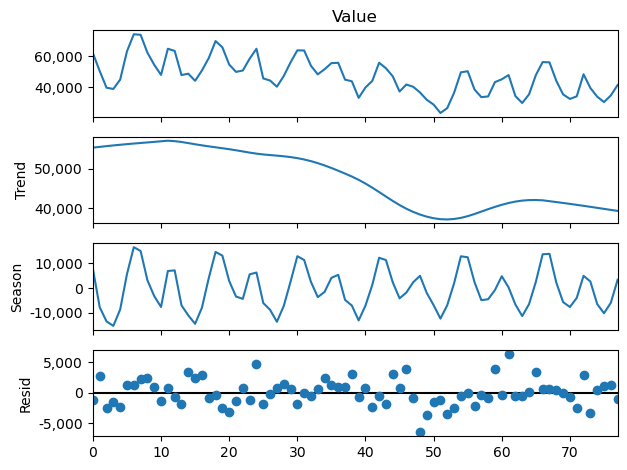

In [14]:
from statsmodels.tsa.seasonal import STL
import matplotlib.pyplot as plt

stl = STL(df['Value'], period=12)
result = stl.fit()

fig = result.plot()
for ax in fig.axes:
    ax.yaxis.set_major_formatter(FuncFormatter(y_format))
    
plt.show()

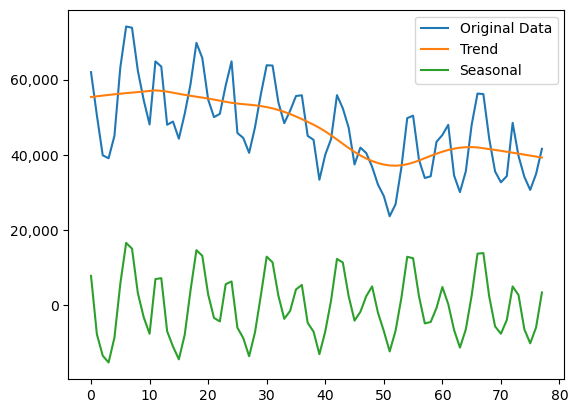

In [15]:
import matplotlib.pyplot as plt

trend = result.trend
seasonal = result.seasonal

plt.plot(df['Value'], label='Original Data')
plt.plot(trend, label='Trend')
plt.plot(seasonal, label='Seasonal')
plt.legend()

plt.gca().yaxis.set_major_formatter(FuncFormatter(y_format))
plt.show()

# ARIMA - AutoRegressive Integrated Moving Average

autoregressive - repeated patterns

integrative - differencing operations

moving average - a more complicated operation

In [16]:
import pandas as pd
from statsmodels.tsa.stattools import adfuller

df = pd.read_csv('MonthlyCoalConsumption.csv')

print('d=0')
result = adfuller(df['Value'])
print('ADF Statistic: ', result[0])
print('p-value: ', result[1])

print('\nd=1')
df1 = df['Value'].diff().dropna()
result = adfuller(df1)
print('ADF Statistic: ', result[0])
print('p-value: ', result[1])

print('\nd=2')
df2 = df1.diff().dropna()
result = adfuller(df2)
print('ADF Statistic: ', result[0])
print('p-value: ', result[1])


d=0
ADF Statistic:  -1.1742897950626652
p-value:  0.684556677289631

d=1
ADF Statistic:  -1.7838215415905343
p-value:  0.38852291349100676

d=2
ADF Statistic:  -8.578323839498001
p-value:  7.852009937903733e-14


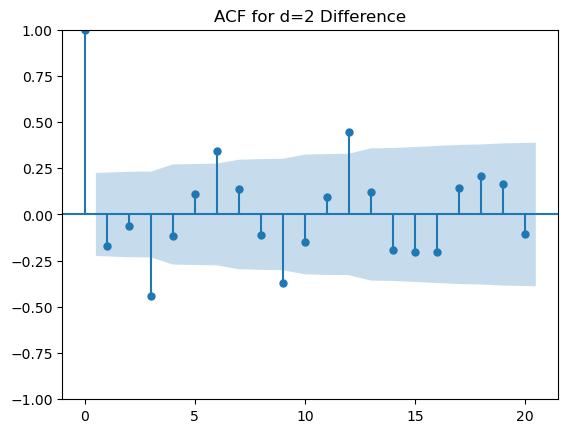

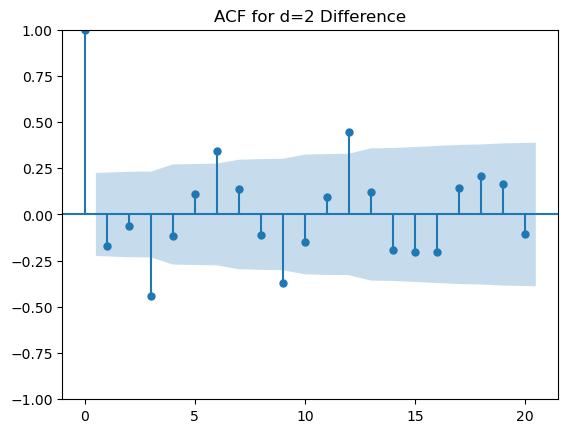

In [17]:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(df2, lags=20, title='ACF for d=2 Difference')

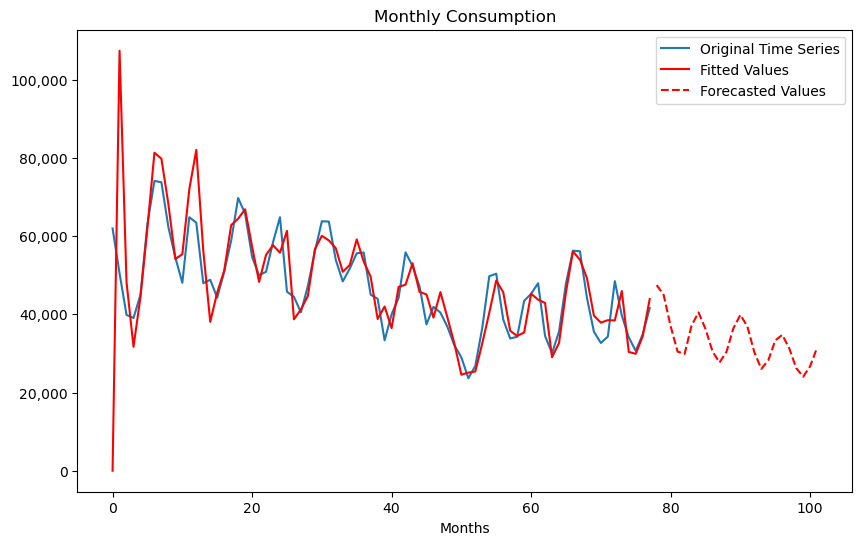

In [21]:
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import FuncFormatter

p=12; d=2; q=0
model = ARIMA(df['Value'], order=(p, d, q))
results = model.fit()

fc = results.forecast(steps = 24)

plt.figure(figsize=(10,6))
plt.plot(df['Value'], label='Original Time Series')
plt.plot(results.fittedvalues, color='red', label='Fitted Values')
plt.plot(fc, color='red', linestyle='dashed', label='Forecasted Values')

plt.xlabel('Months')
plt.title('Monthly Consumption')
plt.legend()

def y_format(value, tick_number):
    return f'{value:,.0f}'

plt.gca().yaxis.set_major_formatter(FuncFormatter(y_format))
plt.show()

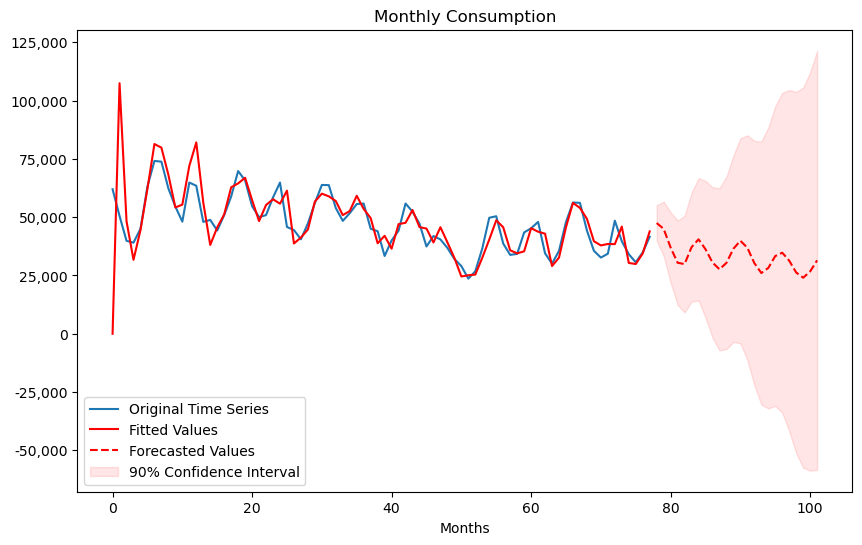

In [23]:
forecast_steps = 24
forecast_results = results.get_forecast(steps=forecast_steps, alpha=0.1)

forecast_values = forecast_results.predicted_mean
confidence_intervals = forecast_results.conf_int()

plt.figure(figsize=(10,6))

plt.plot(df['Value'], label='Original Time Series')
plt.plot(results.fittedvalues, color='red', label='Fitted Values')
plt.plot(forecast_values, color='red', linestyle='dashed', label='Forecasted Values')

plt.fill_between(
    range(len(df), len(df) + forecast_steps),
    confidence_intervals.iloc[:, 0],
    confidence_intervals.iloc[:, 1],
    color='red', alpha=0.1,
    label='90% Confidence Interval')

plt.xlabel('Months')
plt.title('Monthly Consumption')
plt.legend()

plt.gca().yaxis.set_major_formatter(FuncFormatter(y_format))
plt.show()

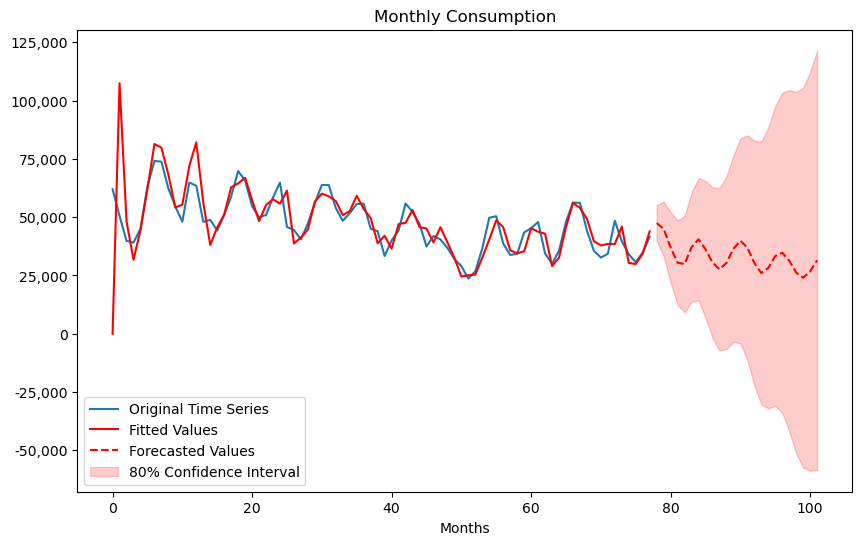

In [24]:
forecast_steps = 24
forecast_results = results.get_forecast(steps=forecast_steps, alpha=0.2)

forecast_values = forecast_results.predicted_mean
confidence_intervals = forecast_results.conf_int()

plt.figure(figsize=(10,6))

plt.plot(df['Value'], label='Original Time Series')
plt.plot(results.fittedvalues, color='red', label='Fitted Values')
plt.plot(forecast_values, color='red', linestyle='dashed', label='Forecasted Values')

plt.fill_between(
    range(len(df), len(df) + forecast_steps),
    confidence_intervals.iloc[:, 0],
    confidence_intervals.iloc[:, 1],
    color='red', alpha=0.2,
    label='80% Confidence Interval')

plt.xlabel('Months')
plt.title('Monthly Consumption')
plt.legend()

plt.gca().yaxis.set_major_formatter(FuncFormatter(y_format))
plt.show()